In [1]:
# ---------------------------------------------------------------
# Kaggle / GPU environment setup (run this cell first)
# ---------------------------------------------------------------
# Requirements on Kaggle:
#   Settings -> Accelerator -> GPU T4 x2 (or P100)
#   Settings -> Internet    -> On   (tensorflow_datasets needs to download the
#                                    Oxford-IIIT Pet dataset the first time)
import subprocess, sys

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import tensorflow_datasets  # noqa: F401
except ImportError:
    _pip_install("tensorflow_datasets")

import os
# Kaggle's default working directory is writable and persists for the session;
# point tfds there instead of the read-only /root default some images use.
os.environ.setdefault("TFDS_DATA_DIR", "/kaggle/working/tensorflow_datasets")

import tensorflow as tf
print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs detected:", gpus if gpus else "None (running on CPU)")

# Enable memory growth so TF doesn't grab all GPU memory up front, and avoids
# a common Kaggle GPU OOM crash when TF pre-allocates the full device.
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print("Could not set memory growth (must be set before GPUs are used):", e)


TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ---------------------------------------------------------------
# 0. Imports and Global Configuration
# ---------------------------------------------------------------
import os, time, json, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

IMG_SIZE = 224
NUM_CHANNELS = 3

# ---------------------------------------------------------------
# Runtime profile: auto-picks a sensible speed/scale trade-off.
#   FAST_MODE = True   -> force the smallest CPU smoke-test profile
#   GPU_MODE           -> auto-selected when a GPU is visible (e.g. Kaggle
#                          T4/P100) and FAST_MODE is False: more data, more
#                          epochs, still finishes in a reasonable session time
#   FULL_MODE (else)   -> CPU, full-scale settings from the lab manual (slow)
# ---------------------------------------------------------------
FAST_MODE = False   # set True to force the tiny CPU smoke-test profile
GPU_AVAILABLE = len(tf.config.list_physical_devices('GPU')) > 0
GPU_MODE = (not FAST_MODE) and GPU_AVAILABLE

if FAST_MODE:
    TRAIN_SUBSET_FRAC = 0.25     # fraction of training data used
    EPOCHS_INIT       = 5        # Section 5 - weight init
    EPOCHS_REG        = 8        # Section 6 - regularization
    EPOCHS_BN         = 6        # Section 7 - batch norm
    EPOCHS_OPT        = 6        # Section 8 - optimizers
    EPOCHS_HP         = 4        # Section 9 - hyperparameter tuning
    EPOCHS_TL         = 6        # Section 10 - transfer learning
    EPOCHS_CV         = 5        # Section 11 - k-fold CV
    EPOCHS_FINAL      = 10       # Section 12 - final model
elif GPU_MODE:
    # Kaggle GPU (T4 x2 / P100): a full conv forward+backward pass is cheap,
    # so we use more of the dataset and more epochs than the CPU smoke test,
    # while staying well inside a single Kaggle session (~9-12h GPU quota).
    TRAIN_SUBSET_FRAC = 0.6
    EPOCHS_INIT       = 10
    EPOCHS_REG        = 12
    EPOCHS_BN         = 10
    EPOCHS_OPT        = 10
    EPOCHS_HP         = 8
    EPOCHS_TL         = 12
    EPOCHS_CV         = 8
    EPOCHS_FINAL      = 18
else:
    # CPU, full scale (matches the lab manual's "real run" sizing) - slow.
    TRAIN_SUBSET_FRAC = 1.0
    EPOCHS_INIT, EPOCHS_REG, EPOCHS_BN = 20, 25, 20
    EPOCHS_OPT, EPOCHS_HP, EPOCHS_TL   = 20, 15, 20
    EPOCHS_CV, EPOCHS_FINAL            = 15, 30

BATCH_SIZE_DEFAULT = 32
AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))
print(f"Runtime profile -> FAST_MODE={FAST_MODE}, GPU_MODE={GPU_MODE}, "
      f"TRAIN_SUBSET_FRAC={TRAIN_SUBSET_FRAC}")


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Runtime profile -> FAST_MODE=False, GPU_MODE=True, TRAIN_SUBSET_FRAC=0.6


In [3]:

# ---------------------------------------------------------------
# 3. Dataset loading and preprocessing
# ---------------------------------------------------------------
import tensorflow_datasets as tfds

# tfds provides the Oxford-IIIT Pet dataset with a 'train' (3680 imgs) and
# 'test' (3669 imgs) split, labeled by breed (37 classes).
# NOTE: requires Kaggle "Internet" to be turned ON (Settings -> Internet) the
# first time this cell runs, so tfds can download and cache the dataset under
# TFDS_DATA_DIR (set in the Kaggle setup cell above).
try:
    (ds_train_full, ds_test_full), ds_info = tfds.load(
        'oxford_iiit_pet',
        split=['train', 'test'],
        with_info=True,
        as_supervised=True,
        data_dir=os.environ.get("TFDS_DATA_DIR"),
    )
except Exception as e:
    raise RuntimeError(
        "Failed to download/load the Oxford-IIIT Pet dataset via "
        "tensorflow_datasets. On Kaggle, make sure Settings -> Internet is "
        "turned ON, then re-run this cell."
    ) from e

NUM_CLASSES = ds_info.features['label'].num_classes
CLASS_NAMES = ds_info.features['label'].names
print(f"Number of classes: {NUM_CLASSES}")
print(f"Train examples: {ds_info.splits['train'].num_examples}, "
      f"Test examples: {ds_info.splits['test'].num_examples}")

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)          # MobileNetV2-specific normalization
    return image, label

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, 0.1)
    return image, label

# Split the official 'train' split further into train/val (80/20)
full_train_size = ds_info.splits['train'].num_examples
val_size = int(0.2 * full_train_size)

ds_train_full = ds_train_full.shuffle(2000, seed=SEED)
ds_val_raw   = ds_train_full.take(val_size)
ds_train_raw = ds_train_full.skip(val_size)

# Optionally subsample training data for fast CPU runs
if TRAIN_SUBSET_FRAC < 1.0:
    keep_n = int((full_train_size - val_size) * TRAIN_SUBSET_FRAC)
    ds_train_raw = ds_train_raw.take(keep_n)

def make_ds(ds_raw, batch_size=BATCH_SIZE_DEFAULT, training=False, shuffle_buf=1000):
    ds = ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(shuffle_buf, seed=SEED)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

ds_train = make_ds(ds_train_raw, training=True)
ds_val   = make_ds(ds_val_raw, training=False)
ds_test  = make_ds(ds_test_full, training=False)

# Cache raw (unbatched, preprocessed) arrays for k-fold CV and for building
# custom small Sequential heads quickly.
def dataset_to_arrays(ds_raw, limit=None):
    xs, ys = [], []
    for img, label in ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE):
        xs.append(img.numpy()); ys.append(label.numpy())
        if limit and len(xs) >= limit:
            break
    return np.array(xs), np.array(ys)

print("Datasets ready: ds_train, ds_val, ds_test")


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1787724402.308422      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787724402.311412      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /kaggle/working/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-train.tf…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /kaggle/working/tensorflow_datasets/oxford_iiit_pet/incomplete.HBRPOI_4.0.0/oxford_iiit_pet-test.tfr…

Dataset oxford_iiit_pet downloaded and prepared to /kaggle/working/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Number of classes: 37
Train examples: 3680, Test examples: 3669
Datasets ready: ds_train, ds_val, ds_test


In [4]:

# ---------------------------------------------------------------
# 4. Utility: build a MobileNetV2-based classifier
# ---------------------------------------------------------------
def build_model(num_classes=NUM_CLASSES,
                 trainable_base=False,
                 unfreeze_from=None,
                 dropout_rate=0.3,
                 l2_reg=0.0,
                 use_batchnorm=True,
                 kernel_initializer='glorot_uniform',
                 input_shape=(IMG_SIZE, IMG_SIZE, NUM_CHANNELS)):
    """Builds MobileNetV2 (ImageNet weights) + custom classification head.

    trainable_base : if True, base conv layers are trainable (fine-tuning)
    unfreeze_from  : layer index from which base layers are unfrozen (fine-tuning)
    dropout_rate   : dropout in the head (0 disables dropout)
    l2_reg         : L2 weight decay coefficient for the head Dense layer
    use_batchnorm  : whether to include a BatchNorm layer in the head
    kernel_initializer : initializer for the head Dense layer (Section 5 study)
    """
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = trainable_base
    if trainable_base and unfreeze_from is not None:
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_regularizer=reg)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                            kernel_initializer=kernel_initializer)(x)
    model = keras.Model(inputs, outputs)
    return model

def compile_model(model, optimizer='adam', lr=1e-3):
    if isinstance(optimizer, str):
        opt_map = {
            'sgd': optimizers.SGD(learning_rate=lr),
            'momentum': optimizers.SGD(learning_rate=lr, momentum=0.9),
            'rmsprop': optimizers.RMSprop(learning_rate=lr),
            'adam': optimizers.Adam(learning_rate=lr),
        }
        optimizer = opt_map[optimizer.lower()]
    model.compile(optimizer=optimizer,
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])
    return model

print("build_model() and compile_model() ready.")


build_model() and compile_model() ready.


In [5]:

# ---------------------------------------------------------------
# Baseline model
# ---------------------------------------------------------------
baseline_model = build_model(trainable_base=False,
                              dropout_rate=0.3,
                              l2_reg=0.0,
                              use_batchnorm=True,
                              kernel_initializer='glorot_uniform')
compile_model(baseline_model, optimizer='adam', lr=1e-3)

t0 = time.time()
history_baseline = baseline_model.fit(ds_train, validation_data=ds_val,
                                       epochs=EPOCHS_REG, verbose=2)
baseline_time = time.time() - t0

baseline_test_loss, baseline_test_acc = baseline_model.evaluate(ds_test, verbose=0)
print(f"Baseline -> Test accuracy: {baseline_test_acc:.4f}, "
      f"Test loss: {baseline_test_loss:.4f}, Train time: {baseline_time:.1f}s")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/12


2026-08-26 06:07:13.406860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:07:13.565406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:07:13.702573: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787724436.367746      93 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-08-26 06:07:27.750312: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-o

56/56 - 48s - 852ms/step - accuracy: 0.5730 - loss: 1.6463 - val_accuracy: 0.8519 - val_loss: 0.7112
Epoch 2/12
56/56 - 10s - 174ms/step - accuracy: 0.8488 - loss: 0.5199 - val_accuracy: 0.9293 - val_loss: 0.3463
Epoch 3/12
56/56 - 10s - 171ms/step - accuracy: 0.8754 - loss: 0.3661 - val_accuracy: 0.9579 - val_loss: 0.1730
Epoch 4/12
56/56 - 10s - 174ms/step - accuracy: 0.9043 - loss: 0.3025 - val_accuracy: 0.9620 - val_loss: 0.1509
Epoch 5/12
56/56 - 10s - 170ms/step - accuracy: 0.9275 - loss: 0.2238 - val_accuracy: 0.9728 - val_loss: 0.0956
Epoch 6/12
56/56 - 10s - 172ms/step - accuracy: 0.9343 - loss: 0.2039 - val_accuracy: 0.9715 - val_loss: 0.0916
Epoch 7/12
56/56 - 10s - 172ms/step - accuracy: 0.9479 - loss: 0.1511 - val_accuracy: 0.9755 - val_loss: 0.0787
Epoch 8/12
56/56 - 9s - 169ms/step - accuracy: 0.9462 - loss: 0.1638 - val_accuracy: 0.9837 - val_loss: 0.0506
Epoch 9/12
56/56 - 9s - 168ms/step - accuracy: 0.9496 - loss: 0.1411 - val_accuracy: 0.9837 - val_loss: 0.0572
Epoch

2026-08-26 06:09:39.322775: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:09:39.478553: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:09:39.615627: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Baseline -> Test accuracy: 0.8885, Test loss: 0.4073, Train time: 153.4s



=== Training with Zero initialization ===
Epoch 1/10
56/56 - 30s - 535ms/step - accuracy: 0.0232 - loss: 3.6111 - val_accuracy: 0.0245 - val_loss: 3.6112
Epoch 2/10
56/56 - 10s - 173ms/step - accuracy: 0.0249 - loss: 3.6110 - val_accuracy: 0.0217 - val_loss: 3.6106
Epoch 3/10
56/56 - 10s - 173ms/step - accuracy: 0.0294 - loss: 3.6107 - val_accuracy: 0.0217 - val_loss: 3.6116
Epoch 4/10
56/56 - 9s - 168ms/step - accuracy: 0.0306 - loss: 3.6110 - val_accuracy: 0.0217 - val_loss: 3.6111
Epoch 5/10
56/56 - 9s - 167ms/step - accuracy: 0.0243 - loss: 3.6110 - val_accuracy: 0.0217 - val_loss: 3.6114
Epoch 6/10
56/56 - 9s - 167ms/step - accuracy: 0.0311 - loss: 3.6108 - val_accuracy: 0.0258 - val_loss: 3.6116
Epoch 7/10
56/56 - 9s - 169ms/step - accuracy: 0.0300 - loss: 3.6107 - val_accuracy: 0.0245 - val_loss: 3.6113
Epoch 8/10
56/56 - 10s - 171ms/step - accuracy: 0.0294 - loss: 3.6111 - val_accuracy: 0.0285 - val_loss: 3.6109
Epoch 9/10
56/56 - 10s - 172ms/step - accuracy: 0.0232 - loss: 3.

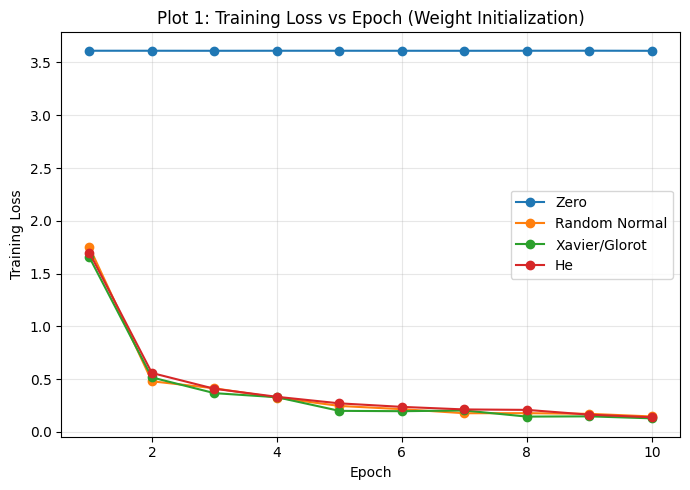

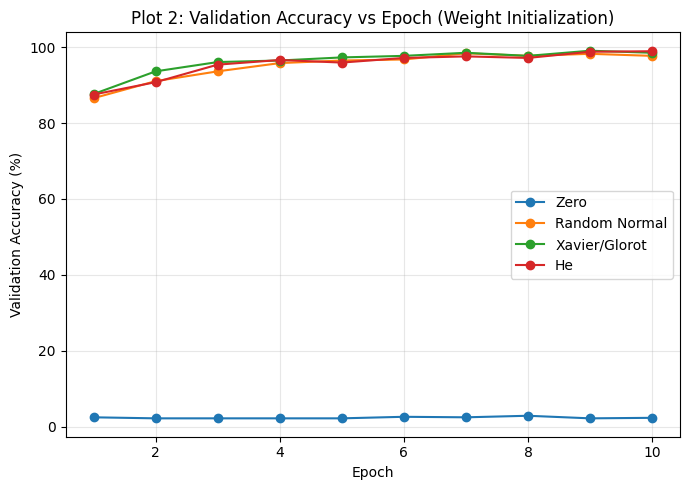

In [6]:

# ---------------------------------------------------------------
# 5. Weight initialization study
# ---------------------------------------------------------------
initializers = {
    'Zero': 'zeros',
    'Random Normal': keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    'Xavier/Glorot': 'glorot_uniform',
    'He': 'he_normal',
}

init_histories = {}
for name, init in initializers.items():
    print(f"\n=== Training with {name} initialization ===")
    m = build_model(kernel_initializer=init, dropout_rate=0.3)
    compile_model(m, optimizer='adam', lr=1e-3)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_INIT, verbose=2)
    init_histories[name] = h.history

# Plot 1: Training Loss vs Epoch
plt.figure(figsize=(7,5))
for name, hist in init_histories.items():
    plt.plot(range(1, len(hist['loss'])+1), hist['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs Epoch (Weight Initialization)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Plot 2: Validation Accuracy vs Epoch
plt.figure(figsize=(7,5))
for name, hist in init_histories.items():
    plt.plot(range(1, len(hist['val_accuracy'])+1),
              np.array(hist['val_accuracy'])*100, marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs Epoch (Weight Initialization)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



=== Training with No Regularization ===
Epoch 1/12
56/56 - 28s - 498ms/step - accuracy: 0.6149 - loss: 1.5240 - val_accuracy: 0.8533 - val_loss: 0.4732
Epoch 2/12
56/56 - 10s - 174ms/step - accuracy: 0.8879 - loss: 0.3675 - val_accuracy: 0.9226 - val_loss: 0.2823
Epoch 3/12
56/56 - 10s - 174ms/step - accuracy: 0.9451 - loss: 0.2183 - val_accuracy: 0.9348 - val_loss: 0.2180
Epoch 4/12
56/56 - 10s - 171ms/step - accuracy: 0.9468 - loss: 0.1912 - val_accuracy: 0.9511 - val_loss: 0.1533
Epoch 5/12
56/56 - 9s - 168ms/step - accuracy: 0.9587 - loss: 0.1544 - val_accuracy: 0.9484 - val_loss: 0.1561
Epoch 6/12
56/56 - 10s - 171ms/step - accuracy: 0.9649 - loss: 0.1204 - val_accuracy: 0.9837 - val_loss: 0.0821
Epoch 7/12
56/56 - 9s - 169ms/step - accuracy: 0.9762 - loss: 0.0911 - val_accuracy: 0.9918 - val_loss: 0.0560
Epoch 8/12
56/56 - 9s - 166ms/step - accuracy: 0.9762 - loss: 0.0840 - val_accuracy: 0.9918 - val_loss: 0.0512
Epoch 9/12
56/56 - 10s - 170ms/step - accuracy: 0.9853 - loss: 0.0

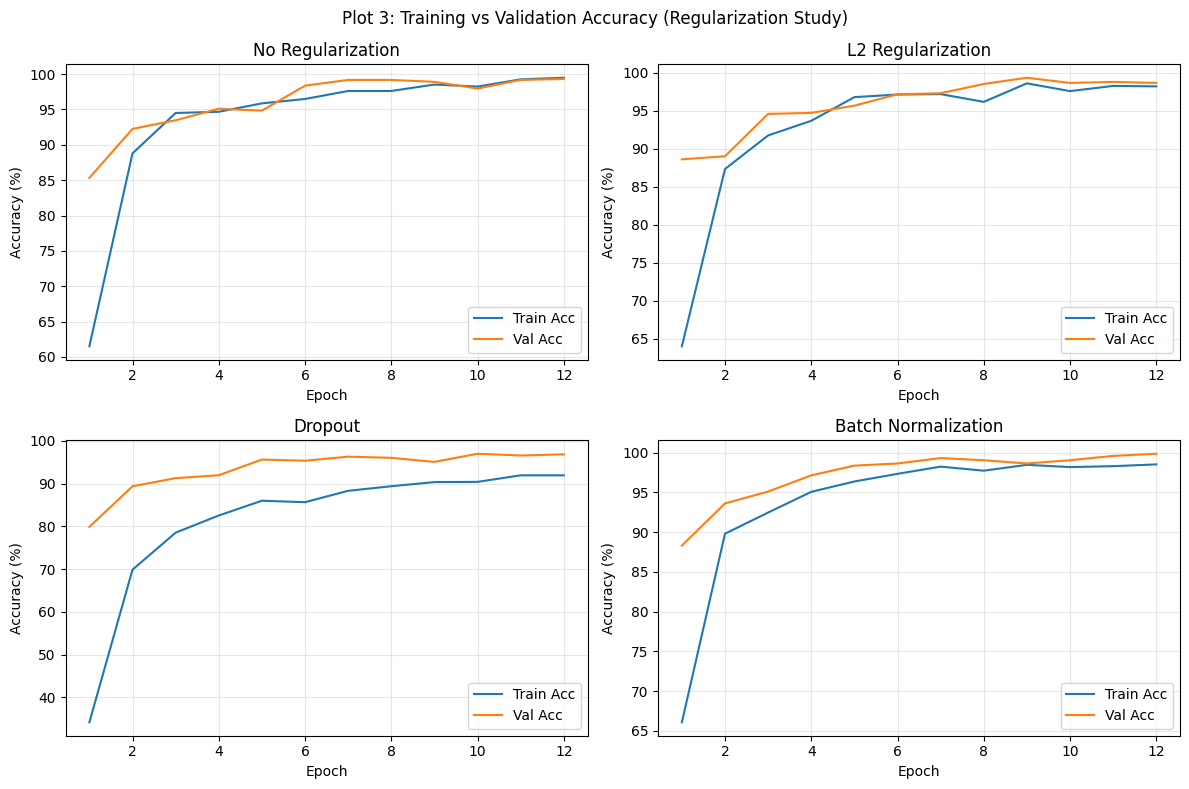

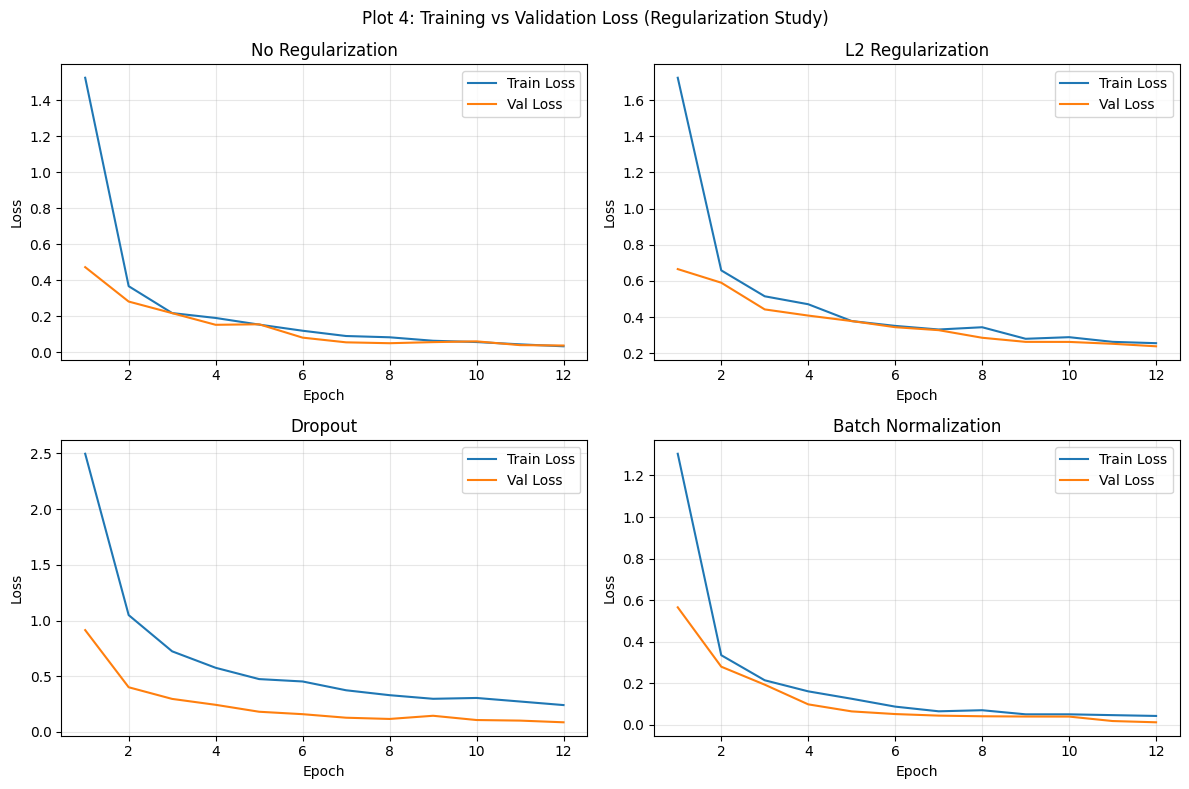


Final-epoch generalization gap (Train Acc - Val Acc):
  No Regularization     : +0.17 pp
  L2 Regularization     : -0.45 pp
  Dropout               : -4.92 pp
  Batch Normalization   : -1.34 pp


In [7]:

# ---------------------------------------------------------------
# 6. Regularization study
# ---------------------------------------------------------------
reg_configs = {
    'No Regularization': dict(dropout_rate=0.0, l2_reg=0.0, use_batchnorm=False),
    'L2 Regularization': dict(dropout_rate=0.0, l2_reg=1e-3, use_batchnorm=False),
    'Dropout':            dict(dropout_rate=0.5, l2_reg=0.0, use_batchnorm=False),
    'Batch Normalization': dict(dropout_rate=0.0, l2_reg=0.0, use_batchnorm=True),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Training with {name} ===")
    m = build_model(kernel_initializer='he_normal', **cfg)
    compile_model(m, optimizer='adam', lr=1e-3)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_REG, verbose=2)
    reg_histories[name] = h.history

# Plot 3: Training & Validation Accuracy vs Epoch (2x2 subplots, one per config)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, hist) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(hist['accuracy'])+1)
    ax.plot(epochs_r, np.array(hist['accuracy'])*100, label='Train Acc')
    ax.plot(epochs_r, np.array(hist['val_accuracy'])*100, label='Val Acc')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Plot 3: Training vs Validation Accuracy (Regularization Study)')
plt.tight_layout(); plt.show()

# Plot 4: Training & Validation Loss vs Epoch
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, hist) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(hist['loss'])+1)
    ax.plot(epochs_r, hist['loss'], label='Train Loss')
    ax.plot(epochs_r, hist['val_loss'], label='Val Loss')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle('Plot 4: Training vs Validation Loss (Regularization Study)')
plt.tight_layout(); plt.show()

# Generalization gap summary
print("\nFinal-epoch generalization gap (Train Acc - Val Acc):")
for name, hist in reg_histories.items():
    gap = (hist['accuracy'][-1] - hist['val_accuracy'][-1]) * 100
    print(f"  {name:22s}: {gap:+.2f} pp")


In [8]:

# ---------------------------------------------------------------
# 7. Batch Normalization - worked numerical example
# ---------------------------------------------------------------
x = np.array([2.0, 4.0, 6.0, 8.0])
mu_B = x.mean()
var_B = ((x - mu_B) ** 2).mean()
eps = 1e-8
x_hat = (x - mu_B) / np.sqrt(var_B + eps)

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"x            = {x}")
print(f"mu_B         = {mu_B}")
print(f"sigma_B^2    = {var_B}")
print(f"sqrt(var_B)  = {np.sqrt(var_B):.3f}")
print(f"x_hat        = {np.round(x_hat, 3)}")
print(f"y (gamma=1, beta=0) = {np.round(y, 3)}")


x            = [2. 4. 6. 8.]
mu_B         = 5.0
sigma_B^2    = 5.0
sqrt(var_B)  = 2.236
x_hat        = [-1.342 -0.447  0.447  1.342]
y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]


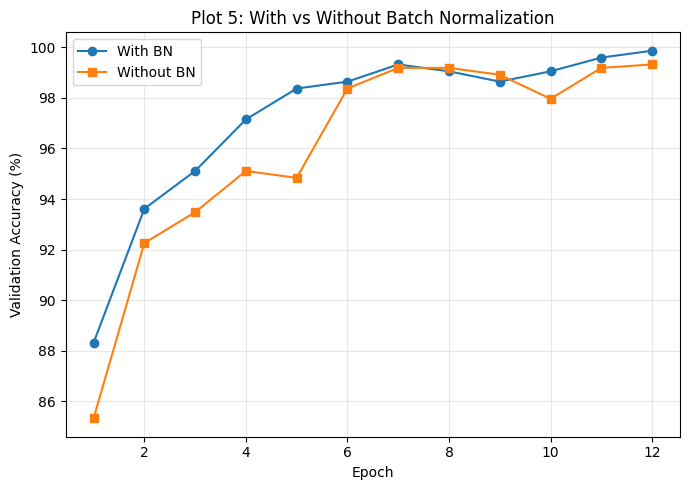

In [9]:

# Plot 5: With vs Without Batch Normalization
plt.figure(figsize=(7,5))
h_with = reg_histories['Batch Normalization']
h_without = reg_histories['No Regularization']
plt.plot(range(1, len(h_with['val_accuracy'])+1),
          np.array(h_with['val_accuracy'])*100, marker='o', label='With BN')
plt.plot(range(1, len(h_without['val_accuracy'])+1),
          np.array(h_without['val_accuracy'])*100, marker='s', label='Without BN')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs Without Batch Normalization')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



=== Training with optimizer: sgd ===
Epoch 1/10
56/56 - 29s - 519ms/step - accuracy: 0.0385 - loss: 4.7111 - val_accuracy: 0.0571 - val_loss: 3.7845
Epoch 2/10
56/56 - 10s - 173ms/step - accuracy: 0.0555 - loss: 4.2829 - val_accuracy: 0.1168 - val_loss: 3.4875
Epoch 3/10
56/56 - 9s - 167ms/step - accuracy: 0.0980 - loss: 3.8411 - val_accuracy: 0.1739 - val_loss: 3.2276
Epoch 4/10
56/56 - 9s - 169ms/step - accuracy: 0.1291 - loss: 3.5423 - val_accuracy: 0.2188 - val_loss: 2.9902
Epoch 5/10
56/56 - 10s - 172ms/step - accuracy: 0.1636 - loss: 3.2387 - val_accuracy: 0.2962 - val_loss: 2.6895
Epoch 6/10
56/56 - 10s - 170ms/step - accuracy: 0.2208 - loss: 2.9625 - val_accuracy: 0.4035 - val_loss: 2.3575
Epoch 7/10
56/56 - 11s - 205ms/step - accuracy: 0.2684 - loss: 2.7343 - val_accuracy: 0.4402 - val_loss: 2.1932
Epoch 8/10
56/56 - 9s - 168ms/step - accuracy: 0.3273 - loss: 2.4839 - val_accuracy: 0.5122 - val_loss: 1.9378
Epoch 9/10
56/56 - 9s - 168ms/step - accuracy: 0.3630 - loss: 2.3247 

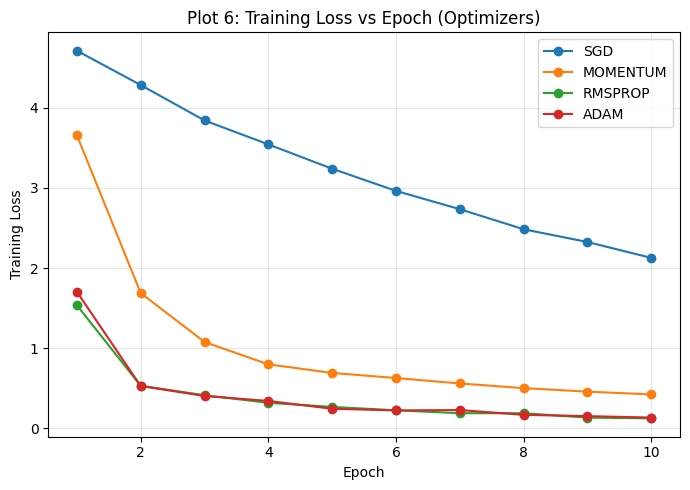

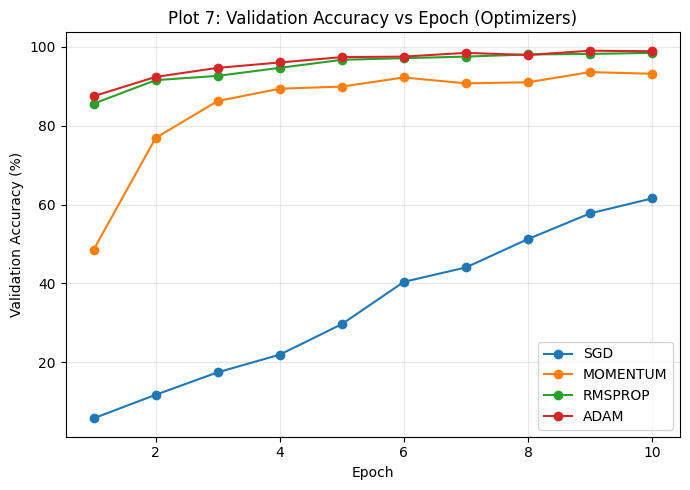

,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,2.1269,61.55,10,116.3
1,MOMENTUM,0.4236,93.61,9,114.2
2,RMSPROP,0.1251,98.51,10,113.9
3,ADAM,0.1350,99.05,9,115.3


In [10]:

# ---------------------------------------------------------------
# 8. Optimizer comparison
# ---------------------------------------------------------------
optimizer_names = ['sgd', 'momentum', 'rmsprop', 'adam']
opt_histories = {}
opt_times = {}

for opt_name in optimizer_names:
    print(f"\n=== Training with optimizer: {opt_name} ===")
    m = build_model(kernel_initializer='he_normal', dropout_rate=0.3, use_batchnorm=True)
    compile_model(m, optimizer=opt_name, lr=1e-3)
    t0 = time.time()
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_OPT, verbose=2)
    opt_times[opt_name] = time.time() - t0
    opt_histories[opt_name] = h.history

# Plot 6: Training Loss vs Epoch
plt.figure(figsize=(7,5))
for name, hist in opt_histories.items():
    plt.plot(range(1, len(hist['loss'])+1), hist['loss'], marker='o', label=name.upper())
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs Epoch (Optimizers)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Plot 7: Validation Accuracy vs Epoch
plt.figure(figsize=(7,5))
for name, hist in opt_histories.items():
    plt.plot(range(1, len(hist['val_accuracy'])+1),
              np.array(hist['val_accuracy'])*100, marker='o', label=name.upper())
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs Epoch (Optimizers)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Optimizer summary table
rows = []
for name, hist in opt_histories.items():
    val_acc = np.array(hist['val_accuracy']) * 100
    best_acc = val_acc.max()
    epoch_converge = int(np.argmax(val_acc)) + 1
    rows.append({
        'Optimizer': name.upper(),
        'Final Loss': round(hist['loss'][-1], 4),
        'Best Val. Accuracy (%)': round(best_acc, 2),
        'Epoch to Converge': epoch_converge,
        'Time (s)': round(opt_times[name], 1),
    })
optimizer_table = pd.DataFrame(rows)
optimizer_table


In [11]:

# ---------------------------------------------------------------
# 9a. Convolution output-size formula check
# ---------------------------------------------------------------
def conv_output_size(N, K, P, S):
    return (N + 2*P - K) // S + 1

# Example: 224x224 input, 3x3 kernel, padding=1, stride=1 -> should stay 224
print("O =", conv_output_size(N=224, K=3, P=1, S=1))
# Example: 224x224 input, 3x3 kernel, padding=0, stride=2 (typical MobileNetV2 stem)
print("O =", conv_output_size(N=224, K=3, P=0, S=2))


O = 224
O = 111



=== Learning rate: 0.001 ===
Epoch 1/8
56/56 - 30s - 532ms/step - accuracy: 0.5396 - loss: 1.8050 - val_accuracy: 0.8791 - val_loss: 0.6997
Epoch 2/8
56/56 - 10s - 173ms/step - accuracy: 0.8443 - loss: 0.5539 - val_accuracy: 0.9239 - val_loss: 0.3359
Epoch 3/8
56/56 - 10s - 171ms/step - accuracy: 0.8822 - loss: 0.3917 - val_accuracy: 0.9511 - val_loss: 0.1903
Epoch 4/8
56/56 - 9s - 166ms/step - accuracy: 0.9003 - loss: 0.3173 - val_accuracy: 0.9524 - val_loss: 0.1548
Epoch 5/8
56/56 - 10s - 172ms/step - accuracy: 0.9077 - loss: 0.2884 - val_accuracy: 0.9457 - val_loss: 0.1735
Epoch 6/8
56/56 - 9s - 169ms/step - accuracy: 0.9230 - loss: 0.2473 - val_accuracy: 0.9715 - val_loss: 0.1083
Epoch 7/8
56/56 - 9s - 168ms/step - accuracy: 0.9417 - loss: 0.1934 - val_accuracy: 0.9769 - val_loss: 0.0746
Epoch 8/8
56/56 - 9s - 168ms/step - accuracy: 0.9366 - loss: 0.1861 - val_accuracy: 0.9715 - val_loss: 0.0938

=== Learning rate: 0.0001 ===
Epoch 1/8
56/56 - 30s - 528ms/step - accuracy: 0.0680 -

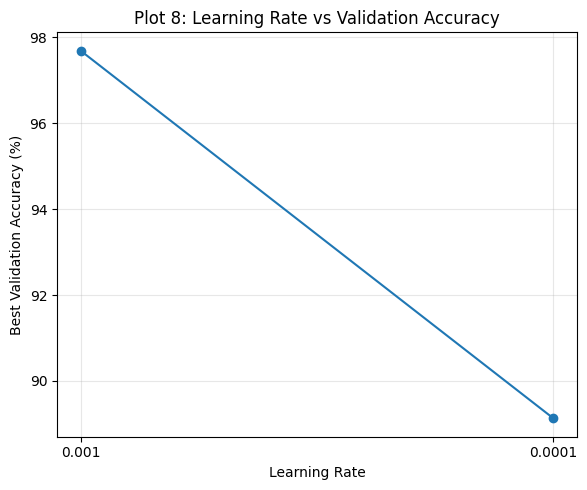

In [12]:

# ---------------------------------------------------------------
# 9b. Learning Rate sweep
# ---------------------------------------------------------------
learning_rates = [1e-3, 1e-4]
lr_results = {}
for lr in learning_rates:
    print(f"\n=== Learning rate: {lr} ===")
    m = build_model(kernel_initializer='he_normal', dropout_rate=0.3, use_batchnorm=True)
    compile_model(m, optimizer='adam', lr=lr)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_HP, verbose=2)
    lr_results[lr] = max(h.history['val_accuracy']) * 100

# Plot 8: Learning Rate vs Validation Accuracy
plt.figure(figsize=(6,5))
plt.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate'); plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs Validation Accuracy')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



=== Batch size: 16 ===
Epoch 1/8


2026-08-26 06:37:53.511864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:37:53.669900: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:37:53.807301: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


111/111 - 40s - 357ms/step - accuracy: 0.5815 - loss: 1.5835 - val_accuracy: 0.8601 - val_loss: 0.5280
Epoch 2/8
111/111 - 10s - 89ms/step - accuracy: 0.8364 - loss: 0.5555 - val_accuracy: 0.9307 - val_loss: 0.2255
Epoch 3/8
111/111 - 10s - 89ms/step - accuracy: 0.8805 - loss: 0.4065 - val_accuracy: 0.9565 - val_loss: 0.1356
Epoch 4/8
111/111 - 10s - 90ms/step - accuracy: 0.8879 - loss: 0.3667 - val_accuracy: 0.9647 - val_loss: 0.1009
Epoch 5/8
111/111 - 10s - 88ms/step - accuracy: 0.8947 - loss: 0.3315 - val_accuracy: 0.9647 - val_loss: 0.1141
Epoch 6/8
111/111 - 10s - 89ms/step - accuracy: 0.9258 - loss: 0.2563 - val_accuracy: 0.9755 - val_loss: 0.0769
Epoch 7/8
111/111 - 10s - 89ms/step - accuracy: 0.9173 - loss: 0.2375 - val_accuracy: 0.9715 - val_loss: 0.0709
Epoch 8/8
111/111 - 10s - 89ms/step - accuracy: 0.9337 - loss: 0.2089 - val_accuracy: 0.9823 - val_loss: 0.0624

=== Batch size: 32 ===
Epoch 1/8
56/56 - 30s - 541ms/step - accuracy: 0.5357 - loss: 1.7689 - val_accuracy: 0.88

2026-08-26 06:41:22.558485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:41:22.697316: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:41:37.419024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 06:41:37.556505: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


28/28 - 52s - 2s/step - accuracy: 0.4706 - loss: 2.0673 - val_accuracy: 0.8098 - val_loss: 1.0656
Epoch 2/8
28/28 - 9s - 339ms/step - accuracy: 0.8182 - loss: 0.5878 - val_accuracy: 0.9226 - val_loss: 0.5001
Epoch 3/8
28/28 - 9s - 339ms/step - accuracy: 0.8901 - loss: 0.3772 - val_accuracy: 0.9293 - val_loss: 0.3413
Epoch 4/8
28/28 - 9s - 321ms/step - accuracy: 0.8998 - loss: 0.3204 - val_accuracy: 0.9457 - val_loss: 0.2350
Epoch 5/8
28/28 - 9s - 333ms/step - accuracy: 0.9190 - loss: 0.2629 - val_accuracy: 0.9660 - val_loss: 0.1646
Epoch 6/8
28/28 - 9s - 327ms/step - accuracy: 0.9207 - loss: 0.2678 - val_accuracy: 0.9810 - val_loss: 0.1109
Epoch 7/8
28/28 - 9s - 330ms/step - accuracy: 0.9360 - loss: 0.1910 - val_accuracy: 0.9796 - val_loss: 0.0912
Epoch 8/8
28/28 - 9s - 328ms/step - accuracy: 0.9524 - loss: 0.1580 - val_accuracy: 0.9851 - val_loss: 0.0750


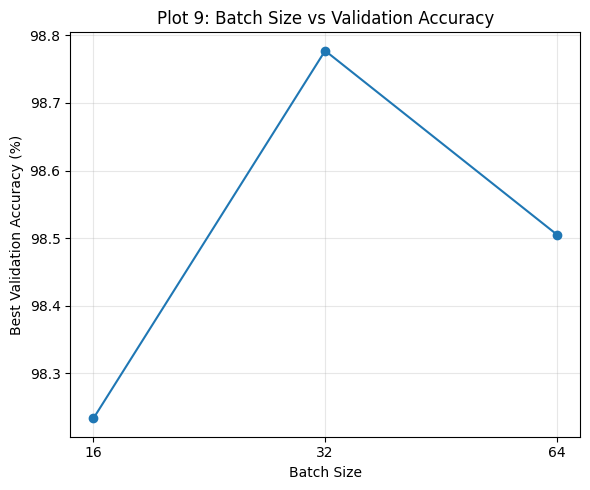

In [13]:

# ---------------------------------------------------------------
# 9c. Batch Size sweep
# ---------------------------------------------------------------
batch_sizes = [16, 32, 64]
bs_results = {}
for bs in batch_sizes:
    print(f"\n=== Batch size: {bs} ===")
    ds_train_bs = make_ds(ds_train_raw, batch_size=bs, training=True)
    ds_val_bs   = make_ds(ds_val_raw, batch_size=bs, training=False)
    m = build_model(kernel_initializer='he_normal', dropout_rate=0.3, use_batchnorm=True)
    compile_model(m, optimizer='adam', lr=1e-3)
    h = m.fit(ds_train_bs, validation_data=ds_val_bs, epochs=EPOCHS_HP, verbose=2)
    bs_results[bs] = max(h.history['val_accuracy']) * 100

# Plot 9: Batch Size vs Validation Accuracy
plt.figure(figsize=(6,5))
plt.plot(list(map(str, bs_results.keys())), list(bs_results.values()), marker='o')
plt.xlabel('Batch Size'); plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs Validation Accuracy')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()



=== Dropout rate: 0.0 ===
Epoch 1/8
56/56 - 29s - 515ms/step - accuracy: 0.6738 - loss: 1.2148 - val_accuracy: 0.9008 - val_loss: 0.5522
Epoch 2/8
56/56 - 10s - 171ms/step - accuracy: 0.8958 - loss: 0.3267 - val_accuracy: 0.9334 - val_loss: 0.2932
Epoch 3/8
56/56 - 9s - 166ms/step - accuracy: 0.9349 - loss: 0.2078 - val_accuracy: 0.9620 - val_loss: 0.1671
Epoch 4/8
56/56 - 9s - 167ms/step - accuracy: 0.9519 - loss: 0.1684 - val_accuracy: 0.9660 - val_loss: 0.1213
Epoch 5/8
56/56 - 10s - 170ms/step - accuracy: 0.9536 - loss: 0.1425 - val_accuracy: 0.9783 - val_loss: 0.0999
Epoch 6/8
56/56 - 10s - 171ms/step - accuracy: 0.9632 - loss: 0.1039 - val_accuracy: 0.9905 - val_loss: 0.0629
Epoch 7/8
56/56 - 10s - 170ms/step - accuracy: 0.9790 - loss: 0.0806 - val_accuracy: 0.9905 - val_loss: 0.0432
Epoch 8/8
56/56 - 9s - 164ms/step - accuracy: 0.9768 - loss: 0.0747 - val_accuracy: 0.9905 - val_loss: 0.0323

=== Dropout rate: 0.25 ===
Epoch 1/8
56/56 - 32s - 566ms/step - accuracy: 0.5713 - loss

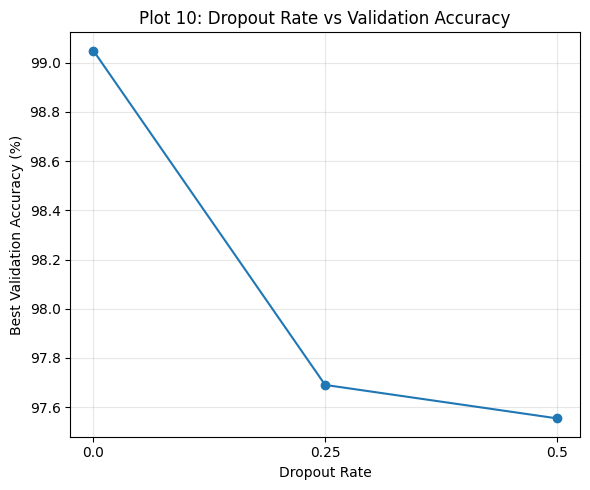


LR results: {0.001: 97.6902186870575, 0.0001: 89.13043737411499}
Batch size results: {16: 98.2336938381195, 32: 98.777174949646, 64: 98.50543737411499}
Dropout results: {0.0: 99.048912525177, 0.25: 97.6902186870575, 0.5: 97.55434989929199}


In [14]:

# ---------------------------------------------------------------
# 9d. Dropout Rate sweep
# ---------------------------------------------------------------
dropout_rates = [0.0, 0.25, 0.5]
dr_results = {}
for dr in dropout_rates:
    print(f"\n=== Dropout rate: {dr} ===")
    m = build_model(kernel_initializer='he_normal', dropout_rate=dr, use_batchnorm=True)
    compile_model(m, optimizer='adam', lr=1e-3)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_HP, verbose=2)
    dr_results[dr] = max(h.history['val_accuracy']) * 100

# Plot 10: Dropout Rate vs Validation Accuracy
plt.figure(figsize=(6,5))
plt.plot(list(map(str, dr_results.keys())), list(dr_results.values()), marker='o')
plt.xlabel('Dropout Rate'); plt.ylabel('Best Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs Validation Accuracy')
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("\nLR results:", lr_results)
print("Batch size results:", bs_results)
print("Dropout results:", dr_results)


In [15]:

# ---------------------------------------------------------------
# 10a. Case A: Feature extraction (frozen base)
# ---------------------------------------------------------------
fe_model = build_model(trainable_base=False, kernel_initializer='he_normal',
                        dropout_rate=0.3, use_batchnorm=True)
compile_model(fe_model, optimizer='adam', lr=1e-3)
history_fe = fe_model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_TL, verbose=2)


Epoch 1/12
56/56 - 31s - 546ms/step - accuracy: 0.5606 - loss: 1.6475 - val_accuracy: 0.8668 - val_loss: 0.6266
Epoch 2/12
56/56 - 10s - 172ms/step - accuracy: 0.8352 - loss: 0.5363 - val_accuracy: 0.9239 - val_loss: 0.3172
Epoch 3/12
56/56 - 10s - 182ms/step - accuracy: 0.8692 - loss: 0.4259 - val_accuracy: 0.9429 - val_loss: 0.1837
Epoch 4/12
56/56 - 10s - 171ms/step - accuracy: 0.9117 - loss: 0.2934 - val_accuracy: 0.9620 - val_loss: 0.1400
Epoch 5/12
56/56 - 9s - 167ms/step - accuracy: 0.9117 - loss: 0.2600 - val_accuracy: 0.9728 - val_loss: 0.0969
Epoch 6/12
56/56 - 9s - 161ms/step - accuracy: 0.9320 - loss: 0.2273 - val_accuracy: 0.9701 - val_loss: 0.0909
Epoch 7/12
56/56 - 11s - 200ms/step - accuracy: 0.9275 - loss: 0.2207 - val_accuracy: 0.9769 - val_loss: 0.0730
Epoch 8/12
56/56 - 10s - 171ms/step - accuracy: 0.9473 - loss: 0.1607 - val_accuracy: 0.9742 - val_loss: 0.0733
Epoch 9/12
56/56 - 9s - 164ms/step - accuracy: 0.9439 - loss: 0.1645 - val_accuracy: 0.9769 - val_loss: 0.

In [16]:

# ---------------------------------------------------------------
# 10b. Case B: Fine-tuning (unfreeze top layers of the base, small LR)
# ---------------------------------------------------------------
# Start from the feature-extraction model's weights, then unfreeze the top of the base.
base_layer = fe_model.layers[1]           # the MobileNetV2 functional sub-model
base_layer.trainable = True
FREEZE_UNTIL = int(len(base_layer.layers) * 0.7)   # keep lower 70% frozen
for layer in base_layer.layers[:FREEZE_UNTIL]:
    layer.trainable = False

compile_model(fe_model, optimizer='adam', lr=1e-5)   # much smaller LR for fine-tuning
history_ft = fe_model.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_TL, verbose=2)

fine_tuned_model = fe_model   # keep a reference; used later for CV / final eval seed


Epoch 1/12
56/56 - 49s - 883ms/step - accuracy: 0.8692 - loss: 0.4264 - val_accuracy: 0.9864 - val_loss: 0.0457
Epoch 2/12
56/56 - 10s - 183ms/step - accuracy: 0.8879 - loss: 0.3510 - val_accuracy: 0.9823 - val_loss: 0.0552
Epoch 3/12
56/56 - 10s - 183ms/step - accuracy: 0.8901 - loss: 0.3340 - val_accuracy: 0.9878 - val_loss: 0.0453
Epoch 4/12
56/56 - 10s - 176ms/step - accuracy: 0.8964 - loss: 0.3082 - val_accuracy: 0.9905 - val_loss: 0.0368
Epoch 5/12
56/56 - 10s - 180ms/step - accuracy: 0.9122 - loss: 0.2861 - val_accuracy: 0.9891 - val_loss: 0.0394
Epoch 6/12
56/56 - 10s - 177ms/step - accuracy: 0.9049 - loss: 0.2733 - val_accuracy: 0.9918 - val_loss: 0.0216
Epoch 7/12
56/56 - 10s - 178ms/step - accuracy: 0.9304 - loss: 0.2402 - val_accuracy: 0.9891 - val_loss: 0.0332
Epoch 8/12
56/56 - 10s - 177ms/step - accuracy: 0.9326 - loss: 0.1976 - val_accuracy: 0.9932 - val_loss: 0.0343
Epoch 9/12
56/56 - 10s - 173ms/step - accuracy: 0.9326 - loss: 0.2137 - val_accuracy: 0.9973 - val_loss:

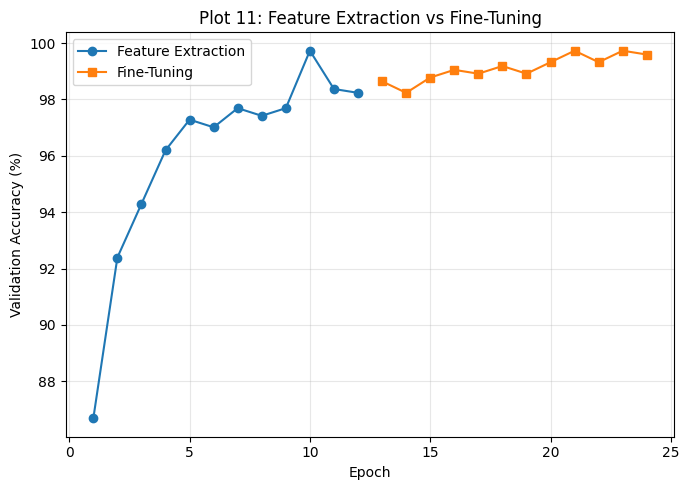

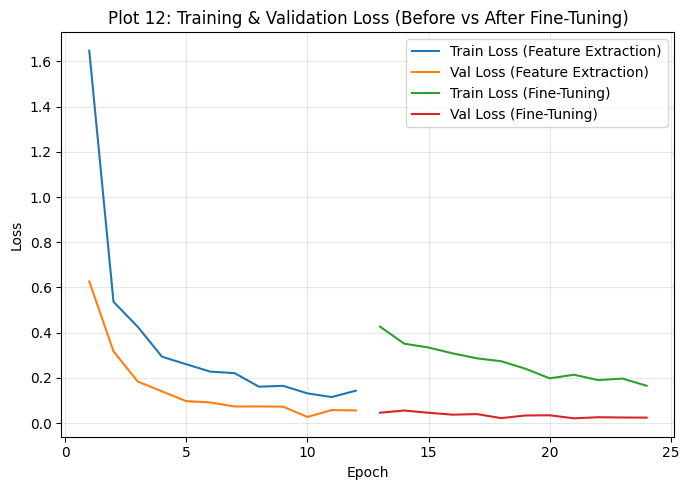

In [17]:

# Plot 11: Feature Extraction vs Fine-Tuning - Validation Accuracy vs Epoch
plt.figure(figsize=(7,5))
plt.plot(range(1, len(history_fe.history['val_accuracy'])+1),
          np.array(history_fe.history['val_accuracy'])*100, marker='o',
          label='Feature Extraction')
ft_start = len(history_fe.history['val_accuracy'])
ft_epochs = range(ft_start+1, ft_start+len(history_ft.history['val_accuracy'])+1)
plt.plot(ft_epochs, np.array(history_ft.history['val_accuracy'])*100, marker='s',
          label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs Fine-Tuning')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Plot 12: Training & Validation Loss before vs after fine-tuning
plt.figure(figsize=(7,5))
plt.plot(range(1, len(history_fe.history['loss'])+1), history_fe.history['loss'],
          label='Train Loss (Feature Extraction)')
plt.plot(range(1, len(history_fe.history['val_loss'])+1), history_fe.history['val_loss'],
          label='Val Loss (Feature Extraction)')
plt.plot(ft_epochs, history_ft.history['loss'], label='Train Loss (Fine-Tuning)')
plt.plot(ft_epochs, history_ft.history['val_loss'], label='Val Loss (Fine-Tuning)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 12: Training & Validation Loss (Before vs After Fine-Tuning)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [18]:

# ---------------------------------------------------------------
# 10c. Fine-tuning hyperparameter sweep: learning rate and frozen-layer strategy
# ---------------------------------------------------------------
# (i) Fine-tuning learning rate sweep, frozen-layer strategy fixed at 70% frozen
ft_lr_values = [1e-4, 1e-5]
ft_lr_results = {}
for lr in ft_lr_values:
    print(f"\n=== Fine-tuning LR: {lr} ===")
    m = build_model(kernel_initializer='he_normal', dropout_rate=0.3, use_batchnorm=True,
                     trainable_base=True)
    # Freeze the bottom 70% of the base, matching the Case B setup above
    base_layer = m.layers[1]
    base_layer.trainable = True
    freeze_until = int(len(base_layer.layers) * 0.7)
    for layer in base_layer.layers[:freeze_until]:
        layer.trainable = False
    compile_model(m, optimizer='adam', lr=lr)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_HP, verbose=2)
    ft_lr_results[lr] = max(h.history['val_accuracy']) * 100

# (ii) Frozen-layer strategy sweep, fine-tuning LR fixed at 1e-5
frozen_strategies = {
    'Frozen base (feature extraction)': None,          # base fully frozen
    'Partial unfreeze (top 30%)': 0.7,                  # freeze bottom 70%
}
frozen_results = {}
for name, freeze_frac in frozen_strategies.items():
    print(f"\n=== Frozen-layer strategy: {name} ===")
    if freeze_frac is None:
        m = build_model(kernel_initializer='he_normal', dropout_rate=0.3,
                         use_batchnorm=True, trainable_base=False)
    else:
        m = build_model(kernel_initializer='he_normal', dropout_rate=0.3,
                         use_batchnorm=True, trainable_base=True)
        base_layer = m.layers[1]
        freeze_until = int(len(base_layer.layers) * freeze_frac)
        for layer in base_layer.layers[:freeze_until]:
            layer.trainable = False
    compile_model(m, optimizer='adam', lr=1e-5 if freeze_frac is not None else 1e-3)
    h = m.fit(ds_train, validation_data=ds_val, epochs=EPOCHS_HP, verbose=2)
    frozen_results[name] = max(h.history['val_accuracy']) * 100

ft_hp_table = pd.DataFrame({
    'Fine-tuning LR sweep (70% frozen)': pd.Series({str(k): round(v, 2) for k, v in ft_lr_results.items()}),
}).combine_first(
    pd.DataFrame({'Frozen-layer strategy sweep (LR fixed)':
                  pd.Series({k: round(v, 2) for k, v in frozen_results.items()})})
)
print("\nFine-tuning LR results (% best val accuracy):", ft_lr_results)
print("Frozen-layer strategy results (% best val accuracy):", frozen_results)



=== Fine-tuning LR: 0.0001 ===
Epoch 1/8
56/56 - 48s - 866ms/step - accuracy: 0.2441 - loss: 3.0843 - val_accuracy: 0.6005 - val_loss: 1.7407
Epoch 2/8
56/56 - 10s - 175ms/step - accuracy: 0.6557 - loss: 1.2262 - val_accuracy: 0.8261 - val_loss: 0.7368
Epoch 3/8
56/56 - 10s - 182ms/step - accuracy: 0.7950 - loss: 0.7380 - val_accuracy: 0.8261 - val_loss: 0.5787
Epoch 4/8
56/56 - 10s - 181ms/step - accuracy: 0.8601 - loss: 0.5109 - val_accuracy: 0.8750 - val_loss: 0.4105
Epoch 5/8
56/56 - 10s - 176ms/step - accuracy: 0.8958 - loss: 0.3913 - val_accuracy: 0.9008 - val_loss: 0.3447
Epoch 6/8
56/56 - 10s - 178ms/step - accuracy: 0.9128 - loss: 0.3209 - val_accuracy: 0.9076 - val_loss: 0.2945
Epoch 7/8
56/56 - 10s - 177ms/step - accuracy: 0.9281 - loss: 0.2751 - val_accuracy: 0.9185 - val_loss: 0.2661
Epoch 8/8
56/56 - 10s - 173ms/step - accuracy: 0.9207 - loss: 0.2757 - val_accuracy: 0.9538 - val_loss: 0.1737

=== Fine-tuning LR: 1e-05 ===
Epoch 1/8
56/56 - 47s - 847ms/step - accuracy: 0.

In [19]:

# ---------------------------------------------------------------
# 11. Build train arrays once (needed for KFold splitting)
# ---------------------------------------------------------------
# Cap the number of examples materialized into in-memory arrays for K-Fold
# splitting (KFold needs a fixed-size array, not a tf.data.Dataset). Even on
# a Kaggle GPU, loading the *entire* training set as raw 224x224x3 float32
# arrays can use a lot of RAM, so we still cap it - just less aggressively
# than the CPU smoke-test profile.
if FAST_MODE:
    CV_LIMIT = 800
elif GPU_MODE:
    CV_LIMIT = 2000
else:
    CV_LIMIT = None
X_cv, y_cv = dataset_to_arrays(ds_train_raw, limit=CV_LIMIT)
print("CV data shape:", X_cv.shape, y_cv.shape)


CV data shape: (1766, 224, 224, 3) (1766,)


In [20]:

# ---------------------------------------------------------------
# 11. Shortlisted configurations (chosen from best results in Sections 5-10)
# ---------------------------------------------------------------
shortlisted_configs = {
    'C1_Baseline':        dict(dropout_rate=0.3, l2_reg=0.0,  use_batchnorm=True,
                                kernel_initializer='glorot_uniform', optimizer='adam', lr=1e-3),
    'C2_BestInit_HeNorm':  dict(dropout_rate=0.3, l2_reg=0.0,  use_batchnorm=True,
                                kernel_initializer='he_normal', optimizer='adam', lr=1e-3),
    'C3_Dropout0.5':       dict(dropout_rate=0.5, l2_reg=0.0,  use_batchnorm=True,
                                kernel_initializer='he_normal', optimizer='adam', lr=1e-3),
    'C4_LowerLR':          dict(dropout_rate=0.3, l2_reg=0.0,  use_batchnorm=True,
                                kernel_initializer='he_normal', optimizer='adam', lr=1e-4),
}

def run_kfold(cfg, X, y, k=5, epochs=EPOCHS_CV):
    kf = KFold(n_splits=k, shuffle=True, random_state=SEED)
    fold_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        m = build_model(kernel_initializer=cfg['kernel_initializer'],
                         dropout_rate=cfg['dropout_rate'],
                         l2_reg=cfg['l2_reg'],
                         use_batchnorm=cfg['use_batchnorm'])
        compile_model(m, optimizer=cfg['optimizer'], lr=cfg['lr'])
        m.fit(X[train_idx], y[train_idx], validation_data=(X[val_idx], y[val_idx]),
              epochs=epochs, batch_size=BATCH_SIZE_DEFAULT, verbose=0)
        _, acc = m.evaluate(X[val_idx], y[val_idx], verbose=0)
        fold_accs.append(acc * 100)
        print(f"  Fold {fold_i}: val accuracy = {acc*100:.2f}%")
    return fold_accs

cv_results = {}
for name, cfg in shortlisted_configs.items():
    print(f"\n=== 5-Fold CV: {name} ===")
    cv_results[name] = run_kfold(cfg, X_cv, y_cv, k=5, epochs=EPOCHS_CV)

# Build results table
cv_table_rows = []
for name, accs in cv_results.items():
    row = {'Configuration': name}
    row.update({f'F{i+1}': round(a, 2) for i, a in enumerate(accs)})
    row['Mean'] = round(np.mean(accs), 2)
    row['SD'] = round(np.std(accs), 2)
    cv_table_rows.append(row)
cv_table = pd.DataFrame(cv_table_rows)
cv_table



=== 5-Fold CV: C1_Baseline ===


2026-08-26 07:00:48.992721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:00:49.129711: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:01:05.602179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:01:05.739380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 1: val accuracy = 89.83%


2026-08-26 07:01:43.514416: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:01:43.650441: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:02:00.302707: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-26 07:02:00.437498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 2: val accuracy = 93.48%
  Fold 3: val accuracy = 87.82%
  Fold 4: val accuracy = 88.39%
  Fold 5: val accuracy = 88.95%

=== 5-Fold CV: C2_BestInit_HeNorm ===
  Fold 1: val accuracy = 90.68%
  Fold 2: val accuracy = 93.77%
  Fold 3: val accuracy = 87.25%
  Fold 4: val accuracy = 89.24%
  Fold 5: val accuracy = 89.52%

=== 5-Fold CV: C3_Dropout0.5 ===
  Fold 1: val accuracy = 88.98%
  Fold 2: val accuracy = 94.33%
  Fold 3: val accuracy = 86.69%
  Fold 4: val accuracy = 88.10%
  Fold 5: val accuracy = 89.80%

=== 5-Fold CV: C4_LowerLR ===
  Fold 1: val accuracy = 82.77%
  Fold 2: val accuracy = 82.72%
  Fold 3: val accuracy = 81.59%
  Fold 4: val accuracy = 79.60%
  Fold 5: val accuracy = 82.44%


,Configuration,F1,F2,F3,F4,F5,Mean,SD
0,C1_Baseline,89.83,93.48,87.82,88.39,88.95,89.69,2.01
1,C2_BestInit_HeNorm,90.68,93.77,87.25,89.24,89.52,90.09,2.14
2,C3_Dropout0.5,88.98,94.33,86.69,88.10,89.80,89.58,2.59
3,C4_LowerLR,82.77,82.72,81.59,79.60,82.44,81.82,1.19


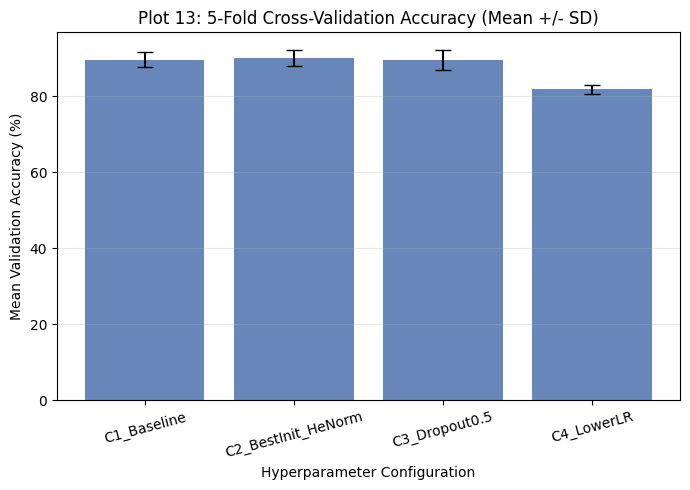


Best configuration by mean CV accuracy: C2_BestInit_HeNorm (90.09 +/- 2.14 %)


In [21]:

# Plot 13: 5-Fold Cross-Validation Accuracy with SD error bars
plt.figure(figsize=(7,5))
names = list(cv_results.keys())
means = [np.mean(cv_results[n]) for n in names]
sds   = [np.std(cv_results[n]) for n in names]
plt.bar(names, means, yerr=sds, capsize=6, color='#4C72B0', alpha=0.85)
plt.xlabel('Hyperparameter Configuration'); plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy (Mean +/- SD)')
plt.xticks(rotation=15); plt.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

best_config_name = max(cv_results, key=lambda n: np.mean(cv_results[n]))
print(f"\nBest configuration by mean CV accuracy: {best_config_name} "
      f"({np.mean(cv_results[best_config_name]):.2f} +/- {np.std(cv_results[best_config_name]):.2f} %)")


In [22]:

# ---------------------------------------------------------------
# 12. Retrain best configuration on full training data
# ---------------------------------------------------------------
best_cfg = shortlisted_configs[best_config_name]
print("Best configuration:", best_config_name, best_cfg)

final_model = build_model(kernel_initializer=best_cfg['kernel_initializer'],
                           dropout_rate=best_cfg['dropout_rate'],
                           l2_reg=best_cfg['l2_reg'],
                           use_batchnorm=best_cfg['use_batchnorm'])
compile_model(final_model, optimizer=best_cfg['optimizer'], lr=best_cfg['lr'])

t0 = time.time()
history_final = final_model.fit(ds_train, validation_data=ds_val,
                                 epochs=EPOCHS_FINAL, verbose=2)
final_train_time = time.time() - t0
n_params = final_model.count_params()
print(f"Final model trained in {final_train_time:.1f}s with {n_params:,} parameters.")


Best configuration: C2_BestInit_HeNorm {'dropout_rate': 0.3, 'l2_reg': 0.0, 'use_batchnorm': True, 'kernel_initializer': 'he_normal', 'optimizer': 'adam', 'lr': 0.001}
Epoch 1/18
56/56 - 28s - 492ms/step - accuracy: 0.5334 - loss: 1.7657 - val_accuracy: 0.8709 - val_loss: 0.6552
Epoch 2/18
56/56 - 9s - 162ms/step - accuracy: 0.8386 - loss: 0.5443 - val_accuracy: 0.9293 - val_loss: 0.3152
Epoch 3/18
56/56 - 9s - 160ms/step - accuracy: 0.8800 - loss: 0.3908 - val_accuracy: 0.9389 - val_loss: 0.2102
Epoch 4/18
56/56 - 9s - 155ms/step - accuracy: 0.8986 - loss: 0.3198 - val_accuracy: 0.9484 - val_loss: 0.1621
Epoch 5/18
56/56 - 9s - 158ms/step - accuracy: 0.9151 - loss: 0.2665 - val_accuracy: 0.9606 - val_loss: 0.1266
Epoch 6/18
56/56 - 9s - 165ms/step - accuracy: 0.9236 - loss: 0.2285 - val_accuracy: 0.9701 - val_loss: 0.1024
Epoch 7/18
56/56 - 9s - 158ms/step - accuracy: 0.9270 - loss: 0.2090 - val_accuracy: 0.9810 - val_loss: 0.0592
Epoch 8/18
56/56 - 9s - 162ms/step - accuracy: 0.9434 

In [23]:

# ---------------------------------------------------------------
# 12. Evaluate on the untouched test set
# ---------------------------------------------------------------
y_true, y_pred = [], []
for imgs, labels in ds_test:
    preds = final_model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())
y_true, y_pred = np.array(y_true), np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

final_metrics = pd.DataFrame({
    'Metric': ['Mean CV Accuracy', 'CV Standard Deviation', 'Test Accuracy',
               'Precision', 'Recall', 'F1-score', 'Training Time (s)', 'Number of Parameters'],
    'Value': [
        round(np.mean(cv_results[best_config_name]), 2),
        round(np.std(cv_results[best_config_name]), 2),
        round(test_accuracy * 100, 2),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(final_train_time, 1),
        n_params,
    ]
})
final_metrics


,Metric,Value
0,Mean CV Accuracy,9.009000e+01
1,CV Standard Deviation,2.140000e+00
2,Test Accuracy,8.921000e+01
3,Precision,8.948000e-01
4,Recall,8.921000e-01
5,F1-score,8.909000e-01
6,Training Time (s),1.819000e+02
7,Number of Parameters,2.431845e+06


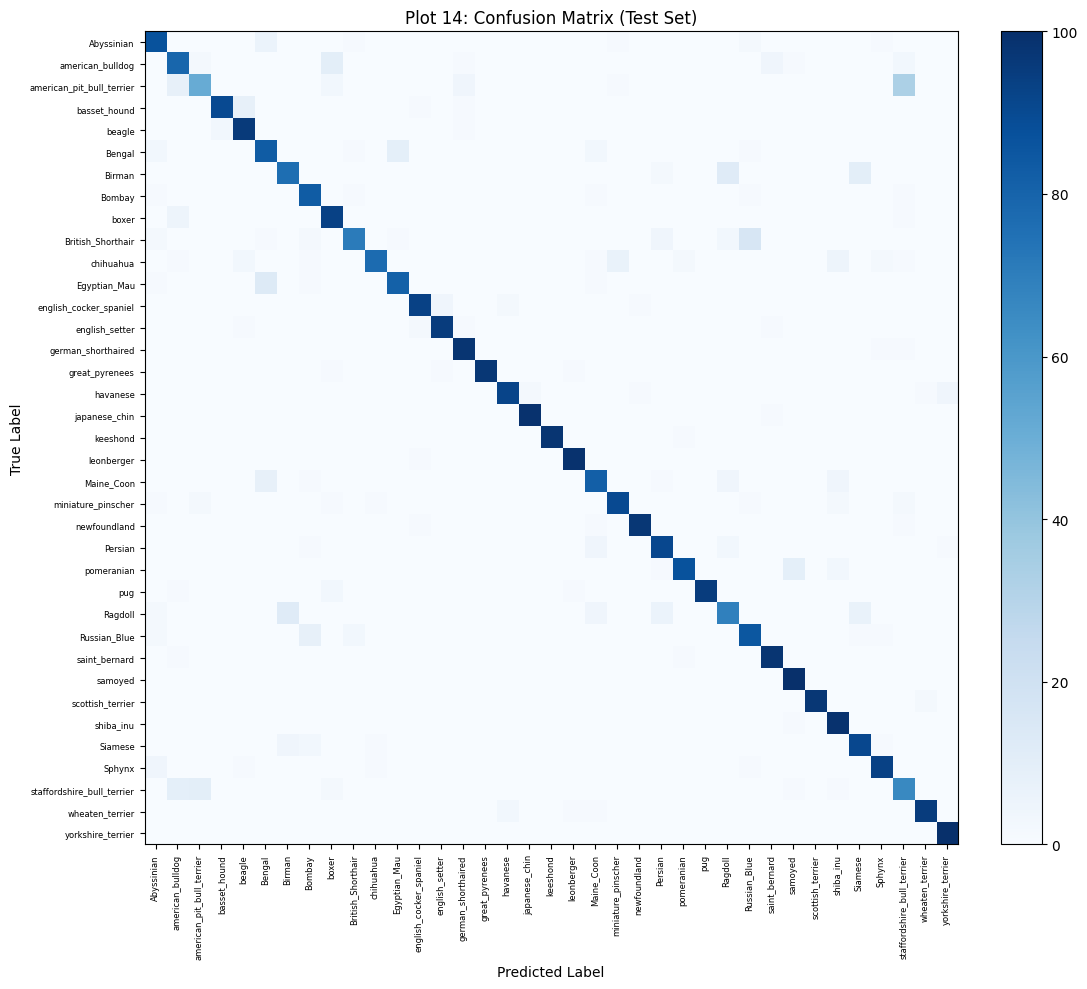

Best classified classes:
  yorkshire_terrier         acc=100.0%
  samoyed                   acc=100.0%
  japanese_chin             acc=99.0%
  shiba_inu                 acc=99.0%
  leonberger                acc=99.0%

Most confused (lowest accuracy) classes:
  american_pit_bull_terrier acc=51.0%
  Ragdoll                   acc=69.0%
  British_Shorthair         acc=71.0%
  staffordshire_bull_terrier acc=74.2%
  Birman                    acc=76.0%


In [24]:

# Plot 14: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues')
plt.title('Plot 14: Confusion Matrix (Test Set)')
plt.xlabel('Predicted Label'); plt.ylabel('True Label')
plt.colorbar(fraction=0.046, pad=0.04)
if NUM_CLASSES <= 40:
    plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=90, fontsize=6)
    plt.yticks(range(NUM_CLASSES), CLASS_NAMES, fontsize=6)
plt.tight_layout(); plt.show()

# Identify best-classified and most-confused classes
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
best_classes = np.argsort(per_class_acc)[::-1][:5]
worst_classes = np.argsort(per_class_acc)[:5]
print("Best classified classes:")
for c in best_classes:
    print(f"  {CLASS_NAMES[c]:25s} acc={per_class_acc[c]*100:.1f}%")
print("\nMost confused (lowest accuracy) classes:")
for c in worst_classes:
    print(f"  {CLASS_NAMES[c]:25s} acc={per_class_acc[c]*100:.1f}%")


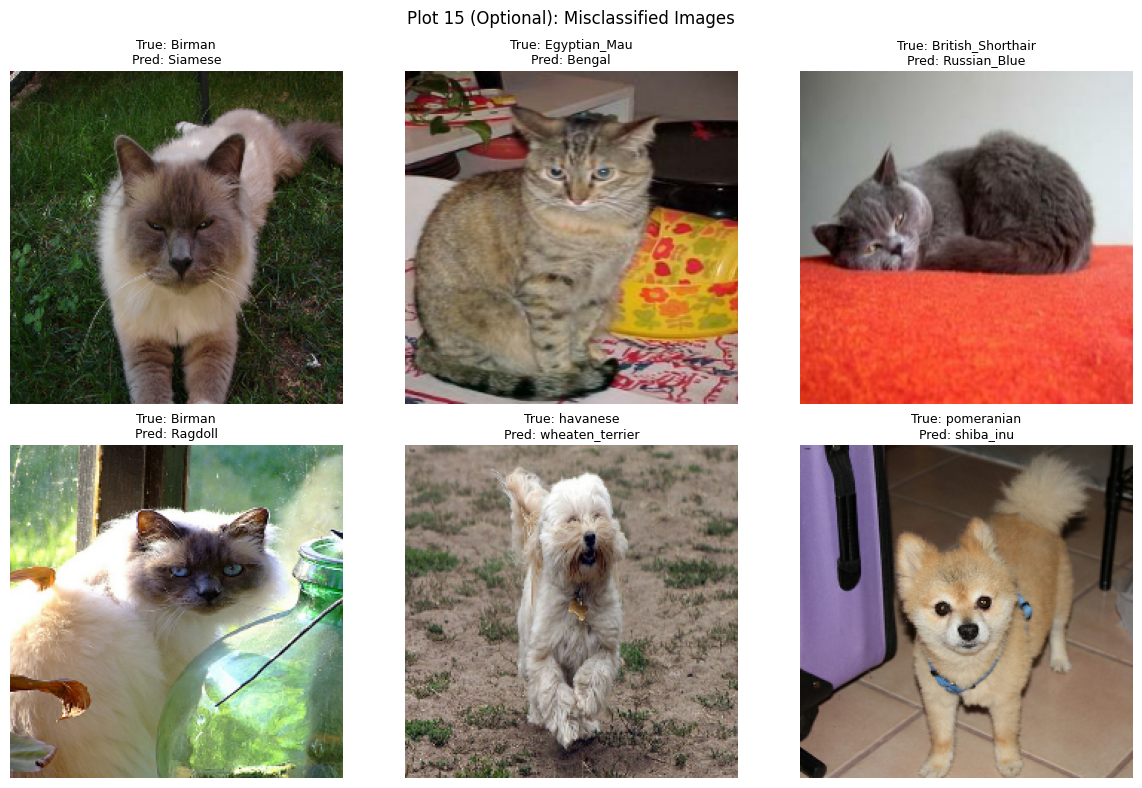

In [25]:

# Plot 15 (Optional): Misclassified Images
mis_idx = np.where(y_true != y_pred)[0]
sample_idx = np.random.choice(mis_idx, size=min(6, len(mis_idx)), replace=False)

# Rebuild a small array of test images (unnormalized for display) aligned to y_true/y_pred order
test_images_raw = []
for imgs, labels in tfds.load('oxford_iiit_pet', split='test', as_supervised=True):
    img = tf.image.resize(imgs, (IMG_SIZE, IMG_SIZE)).numpy().astype('uint8')
    test_images_raw.append(img)
    if len(test_images_raw) >= len(y_true):
        break

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(test_images_raw[idx])
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
fig.suptitle('Plot 15 (Optional): Misclassified Images')
plt.tight_layout(); plt.show()


In [26]:

# ---------------------------------------------------------------
# 13. Overall results table
# ---------------------------------------------------------------
def best_val_acc(hist_dict):
    return max(hist_dict['val_accuracy']) * 100

overall_rows = [
    {'Configuration': 'Baseline',
     'CV Accuracy': '-', 'SD': '-',
     'Test Accuracy (%)': round(baseline_test_acc*100, 2),
     'Training Time (s)': round(baseline_time, 1)},
    {'Configuration': 'Best Initialization (He)',
     'CV Accuracy': '-', 'SD': '-',
     'Test Accuracy (%)': round(best_val_acc(init_histories['He']), 2),
     'Training Time (s)': '-'},
    {'Configuration': 'Best Regularization (Dropout)',
     'CV Accuracy': '-', 'SD': '-',
     'Test Accuracy (%)': round(best_val_acc(reg_histories['Dropout']), 2),
     'Training Time (s)': '-'},
    {'Configuration': 'Best Optimizer (Adam)',
     'CV Accuracy': '-', 'SD': '-',
     'Test Accuracy (%)': round(best_val_acc(opt_histories['adam']), 2),
     'Training Time (s)': round(opt_times['adam'], 1)},
    {'Configuration': 'Best Hyperparameters (' + best_config_name + ')',
     'CV Accuracy': round(np.mean(cv_results[best_config_name]), 2),
     'SD': round(np.std(cv_results[best_config_name]), 2),
     'Test Accuracy (%)': '-', 'Training Time (s)': '-'},
    {'Configuration': 'Fine-Tuned Model',
     'CV Accuracy': '-', 'SD': '-',
     'Test Accuracy (%)': round(best_val_acc(history_ft.history), 2),
     'Training Time (s)': '-'},
    {'Configuration': 'FINAL MODEL (retrained + tested)',
     'CV Accuracy': round(np.mean(cv_results[best_config_name]), 2),
     'SD': round(np.std(cv_results[best_config_name]), 2),
     'Test Accuracy (%)': round(test_accuracy*100, 2),
     'Training Time (s)': round(final_train_time, 1)},
]
overall_results = pd.DataFrame(overall_rows)
overall_results


,Configuration,CV Accuracy,SD,Test Accuracy (%),Training Time (s)
0,Baseline,-,-,88.85,153.4
1,Best Initialization (He),-,-,98.91,-
2,Best Regularization (Dropout),-,-,97.01,-
3,Best Optimizer (Adam),-,-,99.05,115.3
4,Best Hyperparameters (C2_BestInit_HeNorm),90.09,2.14,-,-
5,Fine-Tuned Model,-,-,99.73,-
6,FINAL MODEL (retrained + tested),90.09,2.14,89.21,181.9


In [27]:

# ---------------------------------------------------------------
# 16. Additional exercise: two new configurations
# ---------------------------------------------------------------
additional_configs = {
    'E1_HighDropout_LowLR_FineTune': dict(
        dropout_rate=0.5, l2_reg=0.0, use_batchnorm=True,
        kernel_initializer='he_normal', optimizer='adam', lr=5e-5),
    'E2_NoDropout_HighLR_FeatureExtract': dict(
        dropout_rate=0.0, l2_reg=1e-4, use_batchnorm=True,
        kernel_initializer='glorot_uniform', optimizer='rmsprop', lr=1e-3),
}

additional_cv_results = {}
for name, cfg in additional_configs.items():
    print(f"\n=== 5-Fold CV: {name} ===")
    additional_cv_results[name] = run_kfold(cfg, X_cv, y_cv, k=5, epochs=EPOCHS_CV)

# Combine with the previously selected best configuration for comparison
comparison_results = dict(cv_results)  # from Section 11
comparison_results.update(additional_cv_results)

comparison_rows = []
for name, accs in comparison_results.items():
    comparison_rows.append({
        'Configuration': name,
        'Mean CV Accuracy (%)': round(np.mean(accs), 2),
        'SD': round(np.std(accs), 2),
    })
comparison_table = pd.DataFrame(comparison_rows).sort_values('Mean CV Accuracy (%)', ascending=False)
comparison_table



=== 5-Fold CV: E1_HighDropout_LowLR_FineTune ===
  Fold 1: val accuracy = 64.41%
  Fold 2: val accuracy = 69.97%
  Fold 3: val accuracy = 58.64%
  Fold 4: val accuracy = 57.79%
  Fold 5: val accuracy = 62.04%

=== 5-Fold CV: E2_NoDropout_HighLR_FeatureExtract ===
  Fold 1: val accuracy = 90.11%
  Fold 2: val accuracy = 94.05%
  Fold 3: val accuracy = 89.52%
  Fold 4: val accuracy = 86.97%
  Fold 5: val accuracy = 89.52%


,Configuration,Mean CV Accuracy (%),SD
1,C2_BestInit_HeNorm,90.09,2.14
5,E2_NoDropout_HighLR_FeatureExtract,90.03,2.28
0,C1_Baseline,89.69,2.01
2,C3_Dropout0.5,89.58,2.59
3,C4_LowerLR,81.82,1.19
4,E1_HighDropout_LowLR_FineTune,62.57,4.40


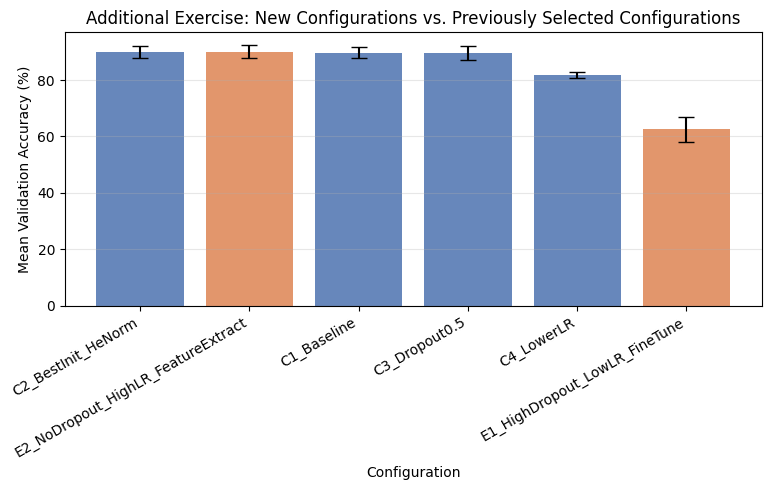


Overall best configuration across ALL candidates: C2_BestInit_HeNorm


In [28]:

# Bar chart comparing all configurations (previous shortlist + 2 new ones)
plt.figure(figsize=(8,5))
names = comparison_table['Configuration']
means = comparison_table['Mean CV Accuracy (%)']
sds = comparison_table['SD']
colors = ['#DD8452' if n in additional_configs else '#4C72B0' for n in names]
plt.bar(names, means, yerr=sds, capsize=6, color=colors, alpha=0.85)
plt.xlabel('Configuration'); plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Additional Exercise: New Configurations vs. Previously Selected Configurations')
plt.xticks(rotation=30, ha='right'); plt.grid(alpha=0.3, axis='y'); plt.tight_layout(); plt.show()

overall_best = comparison_table.iloc[0]['Configuration']
print(f"\nOverall best configuration across ALL candidates: {overall_best}")
